## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)

## 2. Load the model and the data

In [2]:
MODEL_PATH = Path("../models/random_forest_tuned.pkl")
model = joblib.load(MODEL_PATH)

FE_DF_PATH = Path("../data/processed/feature_engineered_df.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)

MODEL_METRICS_PATH = Path("../data/processed/best_model_metrics.csv")
model_metrics_df = pd.read_csv(MODEL_METRICS_PATH)

MODEL_CV_RESULTS = Path("../data/processed/cv_results.csv")
model_cv_results_df = pd.read_csv(MODEL_CV_RESULTS)

## 3. Recreate the train-test split

In [3]:
X = fe_df.drop("log_price", axis=1)
y = fe_df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

## 4. Predictions and metrics

In [4]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_results = pd.DataFrame({
        "R² score": r2_score(y_train, train_pred),
        "MAE": mean_absolute_error(y_train, train_pred),
        "RMSE": root_mean_squared_error(y_train, train_pred),
    }, index=["Training Set"]
)

test_results = pd.DataFrame({
        "R² score": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": root_mean_squared_error(y_test, test_pred),
    }, index=["Test Set"]
)

# look at the training results
train_results.head()

,R² score,MAE,RMSE
Training Set,0.909425,0.154661,0.215949


In [5]:
# look at the test results
test_results.head()

,R² score,MAE,RMSE
Test Set,0.710053,0.277084,0.385945


## 5. Overfitting analysis

The model shows moderate overfitting as shown by the 0.9 R² score on the training set and the 0.7 score on the test set. This is expected from ensemble models despite hyperparameter tuning.

## 6. Actual vs Predicted plot

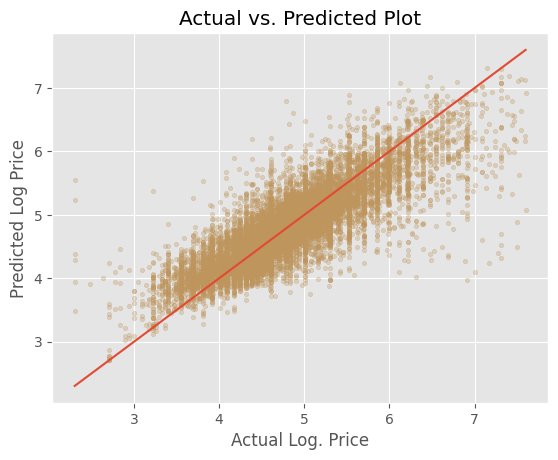

In [ ]:
plt.style.use("ggplot")
plt.scatter(y_test, test_pred, color="#be955c", s=10, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Log. Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs. Predicted Plot")
plt.show()

The points are distributed close to the diagonal at first but, as home prices increase, the spread increases, indicating the model struggling with higher-priced properties.

## 7. Residuals histogram

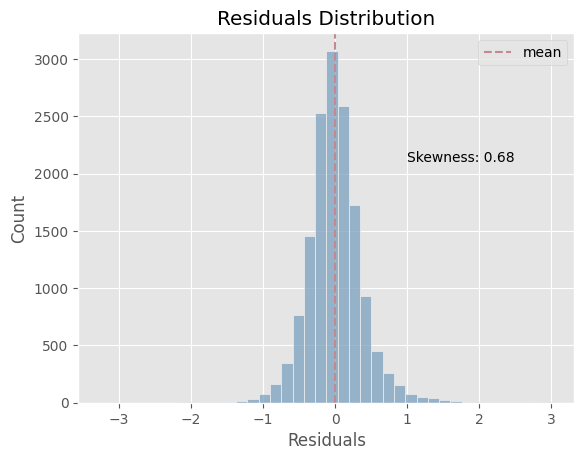

In [ ]:
residuals = y_test - test_pred
residuals_skew = stats.skew(residuals)

sns.histplot(residuals, bins=40, color="#7ca1c0")
plt.axvline(np.array(residuals).mean(), linestyle="--", color="#c38890", label="mean")
plt.text(x=1, y=2100, s=f"Skewness: {residuals_skew:.2f}")
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.legend(loc="best")
plt.show()

The residuals distribution looks normally distributed but the 0.68 skewness value indicates some large residual values in the right tail. As the previous plots also showed, the model predicts too low for large houses prices.

## 8. Residuals scatter plot

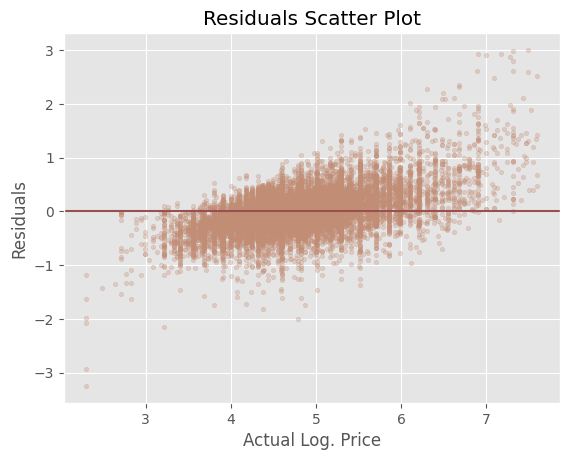

In [ ]:
plt.scatter(y_test, residuals, s=10, color="#c28d75", alpha=0.3)
plt.title("Residuals Scatter Plot")
plt.xlabel("Actual Log. Price")
plt.ylabel("Residuals")
plt.axhline(y=0, color="#9a4f50")
plt.show()

The residuals plot shows mostly randomness around the 0 line. However, the graph tends to create a funnel shape as log. prices increase, meaning that, for large prices, the model struggles to predict them. The model becomes uncertain as values increase.

## 9. Feature importance

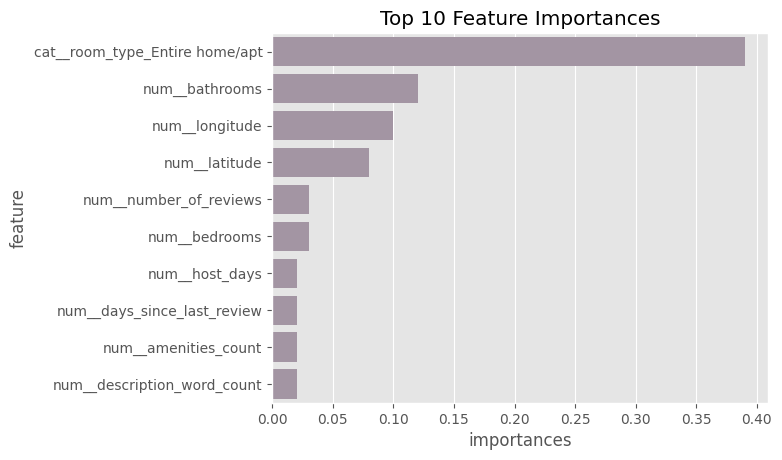

In [ ]:
preprocessor = model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
rand_forest_model = model.named_steps["model"]

feature_importances_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importances": rand_forest_model.feature_importances_,
    }
).round(2).sort_values(by="importances", ascending=False)

# most important features
top_ten_feature_importances = feature_importances_df.nlargest(10, columns="importances")

# plot them
sns.barplot(data=top_ten_feature_importances, x="importances", y="feature", orient="h", color="#a593a5")
plt.title("Top 10 Feature Importances")
plt.show()

The most important feature to predict house price is ```Entire home/apt``` room type, accounting for 0.39 of the totals. 

Importantly, geographical features such as ```longitude``` and ```latitude``` also are in the top five, suggesting that also geographical data matters when predicting house price.

Feature-engineered features such as ```host_days```, ```days_since_last_review```, ```amenities_count``` and ```description_word_count``` show relatively little prediction value (0.02). This suggests that house price is based largely on its room type, bathrooms, geographical data and number of reviews, which makes sense overall.

## 10. Model metrics

In [10]:
# look at the metrics
model_metrics_df.head()

,Model Name,CV Mean R² score,CV Std,Test R² score,MAE,RMSE
0,Random Forest (Tuned),0.7,0.0,0.71,0.28,0.39


Tuned random forest model shows a relatively high Test R² score (0.71), which is rougly the same as the CV Mean R² score (0.7). This indicates the model didn't get a favorable split and generalizes well. The model also achieves a MAE of 0.28 in logarithmic price units. The higher RMSE (0.39) compared to the MAE suggests that, by penalizing large mistakes, the model's predictions miss the logarithmic house prices by about €0.39.

## 11. CV results

In [11]:
# look at the CV results
model_cv_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,19.538000,12.078301,0.149898,0.057549,10,1,2,100,"{'model__max_depth': 10, 'model__min_samples_l...",0.664660,0.667667,0.671865,0.668064,0.002955,15
1,48.988925,2.890829,0.262590,0.091148,10,1,2,200,"{'model__max_depth': 10, 'model__min_samples_l...",0.664838,0.668073,0.672510,0.668473,0.003145,13
2,12.868853,1.313727,0.110403,0.005427,10,1,10,100,"{'model__max_depth': 10, 'model__min_samples_l...",0.664654,0.667658,0.671772,0.668028,0.002918,16
3,70.742804,6.702893,0.282221,0.020560,10,1,10,200,"{'model__max_depth': 10, 'model__min_samples_l...",0.664745,0.668061,0.672334,0.668380,0.003106,14
4,39.376422,0.811203,0.205345,0.016936,10,2,2,100,"{'model__max_depth': 10, 'model__min_samples_l...",0.666778,0.671180,0.673716,0.670558,0.002866,11


In [12]:
# what are the best parameters based on the test score?
best = model_cv_results_df.sort_values("mean_test_score", ascending=False).head(10)

best[["param_model__n_estimators", "param_model__max_depth", "param_model__min_samples_leaf", "param_model__min_samples_split"]]

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split
13,200,20,2,2
15,200,20,2,10
12,100,20,2,2
14,100,20,2,10
9,200,20,1,2
11,200,20,1,10
8,100,20,1,2
10,100,20,1,10
5,200,10,2,2
7,200,10,2,10


In [13]:
# best parameters
best_model = model_cv_results_df.sort_values(by="rank_test_score").iloc[0]
best_model[["params", "mean_test_score", "std_test_score"]]

params             {'model__max_depth': 20, 'model__min_samples_l...
mean_test_score                                             0.699681
std_test_score                                              0.003935
Name: 13, dtype: object

## 12. Convert predictions back to dollar

In [14]:
actual_price = np.exp(y_test)
predicted_price = np.exp(test_pred)

# euros MAE
mae_euros = round(mean_absolute_error(actual_price, predicted_price), 2)
print(f"€ MAE: {mae_euros}")

€ MAE: 49.89


On average, the model's predictions are wrong by about €49.89.

## 13. Error analysis

In [15]:
results_df = X_test.copy()

results_df["actual"] = y_test
results_df["predicted"] = test_pred
results_df["error"] = abs(y_test - test_pred)

# largest errors
results_df.sort_values("error", ascending=False).head(10)

,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,host_identity_verified,...,has_heating,description_length,description_word_count,does_host_respond,accommodates_per_bedroom,beds_per_bedroom,bathrooms_per_bedroom,actual,predicted,error
69004,House,Entire home/apt,1,0.5,Real Bed,flexible,0,SF,t,t,...,0,47,9,0,0.0,0.0,0.0,2.302585,5.549390,3.246805
12047,House,Entire home/apt,2,1.0,Real Bed,strict,0,LA,t,t,...,0,1000,184,1,2.0,2.0,1.0,7.495542,4.488492,3.007050
5843,House,Private room,1,1.0,Real Bed,flexible,0,LA,t,t,...,1,162,29,0,1.0,1.0,1.0,7.313220,4.321467,2.991753
11615,House,Private room,1,1.0,Real Bed,flexible,0,DC,t,t,...,0,1000,170,0,1.0,1.0,1.0,7.170120,4.234952,2.935168
1623,Apartment,Private room,1,1.0,Real Bed,flexible,0,NYC,t,f,...,1,184,27,0,1.0,1.0,1.0,6.907755,3.979032,2.928723
66762,Apartment,Entire home/apt,4,1.0,Real Bed,strict,1,NYC,t,t,...,1,508,88,1,2.0,1.0,0.5,2.302585,5.229709,2.927124
48430,Apartment,Private room,1,1.0,Real Bed,flexible,0,NYC,t,f,...,1,234,37,0,1.0,1.0,1.0,7.003065,4.091531,2.911534
64343,Apartment,Private room,1,1.0,Real Bed,strict,0,NYC,t,f,...,1,456,81,0,1.0,1.0,1.0,7.279319,4.402758,2.876561
72468,Condominium,Private room,2,1.5,Real Bed,flexible,0,LA,t,f,...,1,19,2,1,2.0,1.0,1.5,7.313220,4.518778,2.794442
72567,Apartment,Private room,1,1.0,Real Bed,strict,0,DC,t,t,...,1,460,78,1,1.0,1.0,1.0,6.887553,4.272855,2.614698


In [16]:
# are rare property types harder?
results_df.groupby("property_type")["error"].mean().sort_values(ascending=False)

property_type
Loft           0.334076
Townhouse      0.332113
Condominium    0.305894
Other          0.293295
House          0.290192
Apartment      0.266531
Name: error, dtype: float64

In [17]:
# are certain cities harder?
results_df.groupby("city")["error"].mean().sort_values(ascending=False)

city
DC         0.377692
SF         0.301263
Chicago    0.293864
Boston     0.264927
LA         0.263689
NYC        0.263017
Name: error, dtype: float64

Model's average errors are greater in certain property types, namely loft, townhouse and condominium. Furthermore, some cities seem to be more easily predicted as suggested by the lower average error.